In [141]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [142]:
from util import *
import os
import torch
import tensorflow as tf
from cnn.model import ConvBlock
import cnn_tf.model as tf_model
import numpy as np

In [143]:
# disable all tensorflow logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [144]:
# Load config file
file_path = os.path.join(os.getcwd(), 'config_files', 'config2.txt')
config_file = load_yaml(file_path)

## Test ConvBlock

In [145]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(1, 6, 6, 3).astype(np.float32)
x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [146]:
kernel = 3
stride = 1
filters = 32
mu=0.9
epsilon=2e-5
conv_block = ConvBlock(kernel = kernel,
                       in_channels = x_torch.shape[3],
                       strides = stride, 
                       filters = filters, 
                       mu=mu,
                       epsilon=epsilon)

In [147]:
tf_conv_block = tf_model.ConvBlock(kernel = kernel,
                                   strides = stride,
                                   filters = filters,
                                   mu=mu, 
                                   epsilon=epsilon)

In [148]:
np.isclose(x_torch, x_tf).all()

True

In [149]:
y_torch = conv_block(x_torch).detach().numpy()
y_tf = tf_conv_block(x_tf, name="conv_block")

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

torch: (1, 6, 6, 32), tensorflow: (1, 6, 6, 32)


c:\Github\qnas_torch\cnn_tf\model.py:68: UserWarning: `tf.layers.conv2d` is deprecated and will be removed in a future version. Please Use `tf.keras.layers.Conv2D` instead.
  return tf.compat.v1.layers.conv2d(inputs=inputs,
c:\Github\qnas_torch\cnn_tf\model.py:90: UserWarning: `tf.layers.batch_normalization` is deprecated and will be removed in a future version. Please use `tf.keras.layers.BatchNormalization` instead. In particular, `tf.control_dependencies(tf.GraphKeys.UPDATE_OPS)` should not be used (consult the `tf.keras.layers.BatchNormalization` documentation).
  return tf.compat.v1.layers.batch_normalization(inputs=inputs,


In [150]:
np.isclose(y_torch, y_tf).all()

False

## Test Max Pooling

In [151]:
from cnn.model import MaxPooling

In [152]:
# create a a image tensor to test the max pooling layer
max_pool = MaxPooling(kernel=3, strides=1)
tf_max_pool = tf_model.MaxPooling(kernel=3, strides=1)

y_tf = tf_max_pool(x_tf, name="max_pool")
y_torch = max_pool(x_torch).detach().numpy()

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

torch: (1, 4, 4, 3), tensorflow: (1, 4, 4, 3)


c:\Github\qnas_torch\cnn_tf\model.py:275: UserWarning: `tf.layers.max_pooling2d` is deprecated and will be removed in a future version. Please use `tf.keras.layers.MaxPooling2D` instead.
  return tf.compat.v1.layers.max_pooling2d(inputs=inputs,


In [153]:
np.isclose(y_torch, y_tf).all()

True

## Test Avg Pooling

In [154]:
from cnn.model import AvgPooling

avg_pool = AvgPooling(kernel=3, strides=1)
y_torch = avg_pool(x_torch).detach().numpy()

tf_avg_pool = tf_model.AvgPooling(kernel=3, strides=1)
y_tf = tf_avg_pool(x_tf, name='avg_pool')

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

torch: (1, 4, 4, 3), tensorflow: (1, 4, 4, 3)


c:\Github\qnas_torch\cnn_tf\model.py:311: UserWarning: `tf.layers.average_pooling2d` is deprecated and will be removed in a future version. Please use `tf.keras.layers.AveragePooling2D` instead.
  return tf.compat.v1.layers.average_pooling2d(inputs=inputs,


In [155]:
np.isclose(y_torch, y_tf).all()

True

## Test Fully Connected Layer

In [156]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(32, 6, 6, 3).astype(np.float32)
x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [157]:
from cnn.model import FullyConnected

# flatten the tensor
num_features = x_torch.shape[1] * x_torch.shape[2] * x_torch.shape[3]
units = 20

fc_torch = FullyConnected(input_features=num_features, units=units)
fc_tf = tf_model.FullyConnected(units=units)

x_tor = torch.reshape(x_torch, [-1, num_features])
x_tfl = tf.reshape(x_tf, [-1, num_features])

y_torch = fc_torch(x_tor).detach().numpy()
y_tf = fc_tf(x_tfl, name='fc')

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

torch: (32, 20), tensorflow: (32, 20)


c:\Github\qnas_torch\cnn_tf\model.py:345: UserWarning: `tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.
  tensor = tf.compat.v1.layers.dense(inputs=inputs,


In [158]:
np.isclose(y_torch, y_tf).all()

False

## Test Pad Feature

In [159]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(1, 6, 6, 8).astype(np.float32)
X1 = np.random.rand(1, 6, 6, 6).astype(np.float32)

x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

x_torch1 = torch.from_numpy(X1)
x_tf1 = tf.convert_to_tensor(X1, dtype=tf.float32)


In [160]:
from cnn.model import pad_features

torch_tensors = [x_torch, x_torch1]
tf_tensors = [x_tf, x_tf1]


torch_padded = pad_features(tensors=torch_tensors)
tf_padded = tf_model.pad_features(tensors=tf_tensors)

torch_padded[0].shape, torch_padded[1].shape, tf_padded[0].shape, tf_padded[1].shape

(torch.Size([1, 6, 6, 8]),
 torch.Size([1, 6, 6, 8]),
 TensorShape([1, 6, 6, 8]),
 TensorShape([1, 6, 6, 8]))

## Test ResidualV1

In [161]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(1, 6, 6, 3).astype(np.float32)
x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [162]:
from cnn.model import ResidualV1

kernel = 3
stride = 1
filters = 32
mu=0.9
epsilon=2e-5
Res_v1 = ResidualV1(kernel = kernel,
                    in_channel = x_torch.shape[3],
                    strides = stride, 
                    filters = filters, 
                    mu=mu,
                    epsilon=epsilon)

In [163]:
Res_v1

ResidualV1(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=2e-05, momentum=0.9, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(32, eps=2e-05, momentum=0.9, affine=True, track_running_stats=True)
)

In [164]:
tf_Res = tf_model.ResidualV1(kernel = kernel,
                       strides = stride, 
                       filters = filters, 
                       mu=mu,
                       epsilon=epsilon)

In [165]:
np.isclose(x_torch, x_tf).all()

True

In [166]:
y_torch = Res_v1(x_torch).detach().numpy()
y_tf = tf_Res(x_tf, name="conv_block")

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

inputs.shape: torch.Size([1, 3, 6, 6])
tensor.shape Layer 1: torch.Size([1, 32, 6, 6])
tensor.shape Layer 2: torch.Size([1, 32, 6, 6])
inputs.shape Layer 2: torch.Size([1, 32, 6, 6])
tensor.shape Pad: torch.Size([1, 32, 6, 6])
torch: (1, 6, 6, 32), tensorflow: (1, 6, 6, 32)


c:\Github\qnas_torch\cnn_tf\model.py:176: UserWarning: `tf.layers.conv2d` is deprecated and will be removed in a future version. Please Use `tf.keras.layers.Conv2D` instead.
  return tf.compat.v1.layers.conv2d(inputs=inputs,
c:\Github\qnas_torch\cnn_tf\model.py:197: UserWarning: `tf.layers.batch_normalization` is deprecated and will be removed in a future version. Please use `tf.keras.layers.BatchNormalization` instead. In particular, `tf.control_dependencies(tf.GraphKeys.UPDATE_OPS)` should not be used (consult the `tf.keras.layers.BatchNormalization` documentation).
  return tf.compat.v1.layers.batch_normalization(inputs=inputs,


In [167]:
np.isclose(y_torch, y_tf).all()

False

## Test ResidualV1Pr

In [168]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(1, 6, 6, 3).astype(np.float32)
x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [169]:
from cnn.model import ResidualV1Pr

kernel = 3
stride = 1
filters = 32
mu=0.9
epsilon=2e-5
Res_v1Pr = ResidualV1Pr(kernel = kernel,
                    in_channel = x_torch.shape[3],
                    strides = stride, 
                    filters = filters, 
                    mu=mu,
                    epsilon=epsilon)

Shortcut connection


In [170]:
Res_v1Pr

ResidualV1Pr(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=2e-05, momentum=0.9, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(32, eps=2e-05, momentum=0.9, affine=True, track_running_stats=True)
  (shortcut): Sequential(
    (0): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=2e-05, momentum=0.9, affine=True, track_running_stats=True)
  )
)

In [171]:
tf_ResPR = tf_model.ResidualV1Pr(kernel = kernel,
                       strides = stride, 
                       filters = filters, 
                       mu=mu,
                       epsilon=epsilon)

In [172]:
y_torch = Res_v1Pr(x_torch).detach().numpy()
y_tf = tf_ResPR(x_tf, name="conv_block")

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

inputs.shape: torch.Size([1, 3, 6, 6])
tensor.shape Layer 1: torch.Size([1, 32, 6, 6])
tensor.shape Layer 2: torch.Size([1, 32, 6, 6])
output.shape: torch.Size([1, 32, 6, 6])
torch: (1, 6, 6, 32), tensorflow: (1, 6, 6, 32)


c:\Github\qnas_torch\cnn_tf\model.py:209: UserWarning: `tf.layers.conv2d` is deprecated and will be removed in a future version. Please Use `tf.keras.layers.Conv2D` instead.
  return tf.compat.v1.layers.conv2d(inputs=inputs,


## Test NetworkGraph

In [239]:
import copy
import qnas_config as cfg
from cnn.model import NetworkGraph

In [240]:
phase = 'evolution'
experiment_path = 'my_exp_config2 '
config_file = 'config_files/config2.txt'

In [241]:
args = {
    'experiment_path': experiment_path,
    'config_file': config_file,
    'data_path': 'cifar10/cifar_tfr_10000',
}

In [242]:
config = cfg.ConfigParameters(args, phase=phase)
config.get_parameters()

In [244]:
fn_dict=config.fn_dict
fn_dict_tf = copy.deepcopy(fn_dict)
fn_dict

{'conv_1_1_32': {'function': 'ConvBlock',
  'params': {'kernel': 1, 'strides': 1, 'filters': 32}},
 'conv_1_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 1, 'strides': 1, 'filters': 64}},
 'conv_3_1_32': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 32}},
 'conv_3_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 64}},
 'conv_3_1_128': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 128}},
 'conv_3_1_256': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 256}},
 'conv_5_1_32': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 32}},
 'conv_5_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 64}},
 'conv_5_1_128': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 128}},
 'max_pool_2_2': {'function': 'MaxPooling',
  'params': {'kernel': 2, 'strides': 2}},
 'avg_pool_2_2': 

In [245]:
net_list = ['conv_3_1_64', 'avg_pool_2_2', 'avg_pool_2_2', 'conv_5_1_64', 'conv_5_1_128', 'conv_5_1_64']

In [246]:
filtered_dict = {key: item for key, item in fn_dict.items() if key in net_list}
filtered_dict

{'conv_3_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 64}},
 'conv_5_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 64}},
 'conv_5_1_128': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 128}},
 'avg_pool_2_2': {'function': 'AvgPooling',
  'params': {'kernel': 2, 'strides': 2}}}

In [247]:
net = NetworkGraph(num_classes=10, mu=0.99, in_channels=3)

In [248]:
filtered_dict

{'conv_3_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 64}},
 'conv_5_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 64}},
 'conv_5_1_128': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 128}},
 'avg_pool_2_2': {'function': 'AvgPooling',
  'params': {'kernel': 2, 'strides': 2}}}

In [249]:
net.create_functions(fn_dict=filtered_dict, net_list=net_list)
net

NetworkGraph(
  (model): Sequential(
    (0): ConvBlock(
      (activation): ReLU()
      (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (batch_norm): BatchNorm2d(64, eps=2e-05, momentum=0.99, affine=True, track_running_stats=True)
    )
    (1): AvgPooling(
      (avg_pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
    )
    (2): AvgPooling(
      (avg_pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
    )
    (3): ConvBlock(
      (activation): ReLU()
      (conv): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (batch_norm): BatchNorm2d(64, eps=2e-05, momentum=0.99, affine=True, track_running_stats=True)
    )
    (4): ConvBlock(
      (activation): ReLU()
      (conv): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (batch_norm): BatchNorm2d(128, eps=2e-05, momentum=0.99, affine=True, track_running_stats=True)
    )
    (5): ConvBlock(
      (activation): ReLU()
      (conv): Conv2d(128, 64, k

In [250]:
X = np.random.rand(32, 64, 64, 3).astype(np.float32)
x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [251]:
logits = net(inputs=x_torch, debug=True)

inputs.shape: torch.Size([32, 64, 64, 3])
f: ConvBlock(
  (activation): ReLU()
  (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batch_norm): BatchNorm2d(64, eps=2e-05, momentum=0.99, affine=True, track_running_stats=True)
)
layer output.shape: torch.Size([32, 64, 64, 64])
f: AvgPooling(
  (avg_pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
)
layer output.shape: torch.Size([32, 32, 32, 64])
f: AvgPooling(
  (avg_pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
)
layer output.shape: torch.Size([32, 16, 16, 64])
f: ConvBlock(
  (activation): ReLU()
  (conv): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (batch_norm): BatchNorm2d(64, eps=2e-05, momentum=0.99, affine=True, track_running_stats=True)
)
layer output.shape: torch.Size([32, 16, 16, 64])
f: ConvBlock(
  (activation): ReLU()
  (conv): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (batch_norm): BatchNorm2d(128, eps=2e-05, momentum=0.99, affine=True,

In [252]:
logits.shape

torch.Size([32, 10])

In [253]:
fn_dict_tf

{'conv_1_1_32': {'function': 'ConvBlock',
  'params': {'kernel': 1, 'strides': 1, 'filters': 32}},
 'conv_1_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 1, 'strides': 1, 'filters': 64}},
 'conv_3_1_32': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 32}},
 'conv_3_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 64}},
 'conv_3_1_128': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 128}},
 'conv_3_1_256': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 256}},
 'conv_5_1_32': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 32}},
 'conv_5_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 64}},
 'conv_5_1_128': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 128}},
 'max_pool_2_2': {'function': 'MaxPooling',
  'params': {'kernel': 2, 'strides': 2}},
 'avg_pool_2_2': 

In [254]:
filtered_dict = {key: item for key, item in fn_dict_tf.items() if key in net_list}

In [255]:
tf_net = tf_model.NetworkGraph(num_classes=10, mu=0.99)
tf_net.create_functions(fn_dict=filtered_dict)

In [256]:
tf_logits = tf_net.create_network(inputs=x_tf,net_list=net_list)
tf_logits.shape

Layer 0: conv_3_1_64
Layer 0 output shape: (32, 64, 64, 64)
Layer 1: avg_pool_2_2
Layer 1 output shape: (32, 32, 32, 64)
Layer 2: avg_pool_2_2
Layer 2 output shape: (32, 16, 16, 64)
Layer 3: conv_5_1_64
Layer 3 output shape: (32, 16, 16, 64)
Layer 4: conv_5_1_128
Layer 4 output shape: (32, 16, 16, 128)
Layer 5: conv_5_1_64
Layer 5 output shape: (32, 16, 16, 64)
FC input shape: (32, 16384)


c:\Github\qnas_torch\cnn_tf\model.py:68: UserWarning: `tf.layers.conv2d` is deprecated and will be removed in a future version. Please Use `tf.keras.layers.Conv2D` instead.
  return tf.compat.v1.layers.conv2d(inputs=inputs,
c:\Github\qnas_torch\cnn_tf\model.py:90: UserWarning: `tf.layers.batch_normalization` is deprecated and will be removed in a future version. Please use `tf.keras.layers.BatchNormalization` instead. In particular, `tf.control_dependencies(tf.GraphKeys.UPDATE_OPS)` should not be used (consult the `tf.keras.layers.BatchNormalization` documentation).
  return tf.compat.v1.layers.batch_normalization(inputs=inputs,
c:\Github\qnas_torch\cnn_tf\model.py:311: UserWarning: `tf.layers.average_pooling2d` is deprecated and will be removed in a future version. Please use `tf.keras.layers.AveragePooling2D` instead.
  return tf.compat.v1.layers.average_pooling2d(inputs=inputs,
c:\Github\qnas_torch\cnn_tf\model.py:345: UserWarning: `tf.layers.dense` is deprecated and will be removed

TensorShape([32, 10])

## Pytorch Dataset

In [263]:
from dataloader import create_loader

: 

: 

In [259]:
train_loader, val_loader = create_loader("VGG16", 'cifar10', ID=True)

100.0%


Extracting ./cifar-10-python.tar.gz to ./
Files already downloaded and verified


In [260]:
for x,y in train_loader:
    print(x.shape), print(y.shape)
    break

torch.Size([24, 3, 32, 32])
torch.Size([24])


In [261]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


training_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100.0%


Extracting data\cifar-10-python.tar.gz to data
Files already downloaded and verified


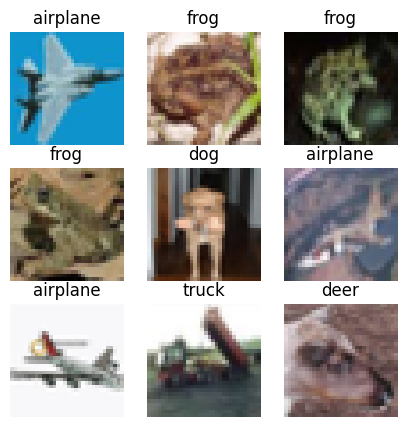

In [262]:
# cifar10 labels map
labels_map = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck",
}
figure = plt.figure(figsize=(5, 5))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze().permute(1, 2, 0))
plt.show()